# Activity 1: Hyperbolic Trees, Horospheres, and a Two-Layer HBNN

[![QR code for the MLSS RDL tutorial repository](https://raw.githubusercontent.com/GitZH-Chen/MLSS-RDL-Tutorial/main/assets/github-repository-qr-260.png)](https://github.com/GitZH-Chen/MLSS-RDL-Tutorial)

**GitHub repository:** [github.com/GitZH-Chen/MLSS-RDL-Tutorial](https://github.com/GitZH-Chen/MLSS-RDL-Tutorial)


## Contents

1. [Mathematical preliminaries](#scrollTo=hbnn-preliminaries)
2. [Setup](#scrollTo=hbnn-setup)
3. [Task 1 — Visualize a binary tree in the Poincaré ball](#scrollTo=task-1-binary-tree)
4. [Task 2 — Visualize the Poincaré and Lorentz models with horospheres](#scrollTo=task-2-horospheres)
5. [Task 3 — Train a two-layer HBNN](#scrollTo=task-3-classification)
6. [Takeaways](#scrollTo=hbnn-takeaways)


## Mathematical preliminaries

For curvature $K<0$, we use the Poincaré and Lorentz models.

$$
\begin{aligned}
\mathbb{P}^n_K
&=\left\{x\in\mathbb{R}^n\mid \lVert x\rVert^2<-1/K\right\},\\[4pt]
\mathbb{L}^n_K
&=\left\{x=[x_t,x_s^\top]^\top\in\mathbb{R}^{n+1}\mid \langle x,x\rangle_{ℒ}=1/K,\ x_t>0\right\},\\[4pt]
\langle x,y\rangle_{ℒ}
&=-x_ty_t+\langle x_s,y_s\rangle,\qquad
ℋ^n_K\in\left\{\mathbb{P}^n_K,\mathbb{L}^n_K\right\}.
\end{aligned}
$$

Let $\gamma$ be a unit-speed geodesic ray. Its Busemann function is

$$
B^\gamma(x)=\lim_{t\to\infty}\left(d(x,\gamma(t))-t\right).
$$

A horosphere is a level set of the Busemann function,

$$
H^v_\tau=\left\{x\in ℋ^n_K\mid B^v(x)=\tau\right\}.
$$

For a unit direction $v\in\mathbb{S}^{n-1}$, the Busemann function has the following expressions.

| Space | Euclidean $\mathbb{R}^{n}$&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; | Poincaré $\mathbb{P}^{n}_{K}$&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; | Lorentz $\mathbb{L}^{n}_{K}$&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; |
|:--|:--|:--|:--|
| Busemann function $B^v(x)$ | $-\langle x,v\rangle$ | $\dfrac{1}{\sqrt{-K}}\log\left(\dfrac{\lVert v-\sqrt{-K}x\rVert^2}{1+K\lVert x\rVert^2}\right)$ | $\dfrac{1}{\sqrt{-K}}\log\left(\sqrt{-K}(x_t-\langle x_s,v\rangle)\right)$ |



The correspondence between the Euclidean and hyperbolic spaces.

| Notion | Euclidean $\mathbb{R}^{n}$&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; | Hyperbolic $ℋ^{n}_{K}$&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; |
|:--|:--|:--|
| Inner product | $\langle v,x\rangle$ | $-B^{v}(x)$ |
| Hyperplane | $H^{v}_{\tau}=\{x\in\mathbb{R}^{n}\mid\langle x,v\rangle=\tau\}$ | $H^{v}_{\tau}=\{x\in ℋ^{n}_{K}\mid B^{v}(x)=\tau\}$ |
| Parallel hyperplanes | Parallel $\{H^{v}_{\tau}\}_{\tau}$ for fixed $v$ | Equidistant $\{H^{v}_{\tau}\}_{\tau}$ for fixed $v$ |
| Logit $u_k(x)$ | $\alpha_k\langle v_k,x\rangle+b_k$ | $-\alpha_kB^{v_k}(x)+b_k$ |


**References**

- Ziheng Chen, Bernhard Schölkopf, and Nicu Sebe. Hyperbolic Busemann Neural Networks. CVPR 2026. [Paper](https://arxiv.org/abs/2602.18858) · [Code](https://github.com/GitZH-Chen/HBNN)

## Setup


In [9]:
%pip -q install geoopt==0.5.1

!test -d /content/mlss_hbnn || git clone -q https://github.com/GitZH-Chen/HBNN.git /content/mlss_hbnn
!git -C /content/mlss_hbnn checkout -q d5c79c8eed36a0b7c2f15e9a8fbcd0318216e5b0

In [10]:
import random
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn

warnings.filterwarnings("ignore", category=SyntaxWarning)
sys.path.insert(0, "/content/mlss_hbnn")

from lib.bnn.BFC import BFC
from lib.bnn.BMLR import BMLR
from lib.bnn.Geometry import Hyperboloid, Stereographic
from lib.bnn.evaluation.vis_horosphere import main as plot_horospheres


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


set_seed(1024)
print("PyTorch:", torch.__version__)

PyTorch: 2.11.0+cpu


## Task 1: Visualize a binary tree in the Poincaré ball

We place each tree level farther from the origin and connect parent–child pairs with Poincaré geodesics.

**Predict:** Why is hyperbolic space well suited to representing a tree as its depth increases?

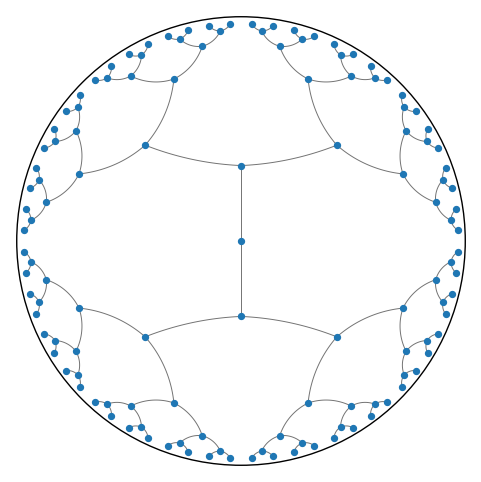

In [23]:
def geodesic_segment(manifold, start, end, steps=40):
    tangent = manifold.log(start, end)
    t = torch.linspace(0, 1, steps).unsqueeze(-1)
    start = start.expand(steps, -1)
    return manifold.exp(start, t * tangent, project=True)


def plot_binary_tree(depth=6, edge_length=0.35):
    manifold = Stereographic(K=-1.0)
    points, edges = [torch.zeros(2)], []
    frontier = [(0, 0.0, 2 * np.pi)]

    for level in range(1, depth + 1):
        next_frontier = []
        for parent, left, right in frontier:
            middle = (left + right) / 2
            for child_left, child_right in ((left, middle), (middle, right)):
                angle = (child_left + child_right) / 2
                direction = torch.tensor([np.cos(angle), np.sin(angle)])
                child = len(points)
                points.append(manifold.exp0(level * edge_length * direction))
                edges.append((parent, child))
                next_frontier.append((child, child_left, child_right))
        frontier = next_frontier

    points = torch.stack(points)
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.add_patch(plt.Circle((0, 0), 1, fill=False, color="black"))
    for parent, child in edges:
        curve = geodesic_segment(manifold, points[parent], points[child])
        ax.plot(curve[:, 0], curve[:, 1], color="0.45", lw=0.7)
    ax.scatter(points[:, 0], points[:, 1], s=18, color="tab:blue", zorder=2)
    ax.set(xlim=(-1.03, 1.03), ylim=(-1.03, 1.03), aspect="equal")
    ax.axis("off")
    plt.show()


depth = 6
plot_binary_tree(depth=depth)

**Interpret:**

- The radial position represents tree depth, while angular sectors separate different branches.
- A binary tree has $2^d$ nodes at depth $d$.
- The circumferences of Euclidean and hyperbolic circles of radius $r$ are

$$
C_{\mathrm{E}}(r)=2\pi r,\qquad C_{\mathrm{H}}(r)=2\pi\sinh(r)\sim\pi e^r.
$$

The Euclidean circumference grows linearly, whereas the hyperbolic circumference grows exponentially and therefore matches the growth of the binary tree.

## Task 2: Visualize horospheres

The two hyperbolic models are

$$
\begin{aligned}
\mathbb{P}^n_K
&=\left\{x\in\mathbb{R}^n\mid\lVert x\rVert^2<-1/K\right\},\\[4pt]
\mathbb{L}^n_K
&=\left\{x=[x_t,x_s^{\top}]^{\top}\in\mathbb{R}^{n+1}\mid\langle x,x\rangle_{ℒ}=1/K,\ x_t>0\right\}.
\end{aligned}
$$

Thus $\mathbb{P}^n_K$ is the interior of the Euclidean ball of radius $1/\sqrt{-K}$, while $\mathbb{L}^n_K$ is the upper sheet of a hyperboloid in Minkowski space ($\mathbb{R}^{n+1}$ equipped with the Lorentz inner product), also called a Minkowski pseudo-sphere.

We focus on the 2-dimensional hyperbolic space, $\mathbb{P}^2_K$ and $\mathbb{L}^2_K$. We fix $K=-1$ and $v=(1,0)$, and visualize the horospheres $H^v_\tau$ in both models.

**Predict:** How should horospheres with the same direction differ as $\tau$ changes?

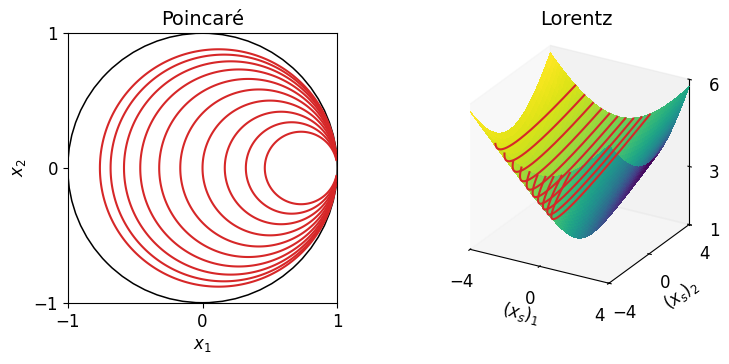

In [12]:
plot_horospheres()

**Interpret:**

- In the Poincaré ball, horospheres with fixed $v$ are circles of different sizes tangent to the boundary at the same point.
- In the Lorentz model, they are intersections of the hyperboloid with a family of parallel Euclidean hyperplanes.

## Task 3: Train a two-layer HBNN

The learnable network is

$$
\mathbb{R}^{2}
\xrightarrow{\operatorname{Exp}_{0}}
\mathbb{P}^{2}_{K}
\xrightarrow{\operatorname{BFC}}
\mathbb{P}^{8}_{K}
\xrightarrow{\operatorname{BMLR}}
\mathbb{R}^{3}.
$$

The exponential map embeds the input. The two trainable layers are BFC and BMLR. Their Euclidean and Busemann formulations are compared below.

| Layer | Expression&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; | Parameters&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; |
|:--|:--|:--|
| Euclidean FC | $y_k=\phi(\langle a_k,x\rangle+b_k),\quad k=1,\ldots,m$ | $a_k\in\mathbb{R}^n,\ b_k\in\mathbb{R}$ |
| Euclidean MLR | $u_k(x)=\langle a_k,x\rangle+b_k,\quad p(y=k\mid x)=\dfrac{e^{u_k(x)}}{\sum_{j=1}^{C}e^{u_j(x)}}$ | $a_k\in\mathbb{R}^n,\ b_k\in\mathbb{R},\quad k=1,\ldots,C$ |
| BFC (Poincaré) | $u_k(x)=\phi(-\alpha_kB^{v_k}(x)+b_k),\quad \omega_k=\dfrac{\sinh(\sqrt{-K}u_k(x))}{\sqrt{-K}},\quad y=\dfrac{\omega}{1+\sqrt{1-K\lVert\omega\rVert^2}}$ | $\alpha_k>0,\ v_k\in\mathbb{S}^{n-1},\ b_k\in\mathbb{R},\quad k=1,\ldots,m$ |
| BMLR | $u_k(x)=-\alpha_kB^{v_k}(x)+b_k,\quad p(y=k\mid x)=\dfrac{e^{u_k(x)}}{\sum_{j=1}^{C}e^{u_j(x)}}$ | $\alpha_k>0,\ v_k\in\mathbb{S}^{n-1},\ b_k\in\mathbb{R},\quad k=1,\ldots,C$ |

### Generate a synthetic dataset

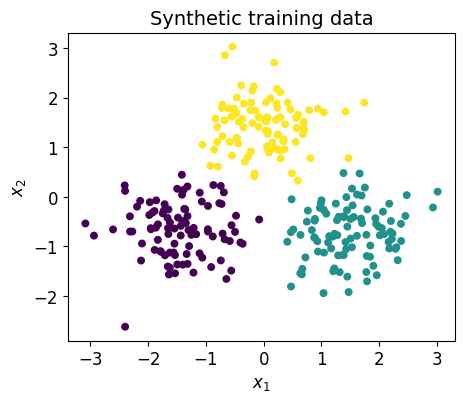

In [13]:
centers = torch.tensor([[-1.5, -0.8], [1.5, -0.8], [0.0, 1.5]])
features = torch.cat([center + 0.55 * torch.randn(120, 2) for center in centers])
labels = torch.arange(3).repeat_interleave(120)

permutation = torch.randperm(len(features))
train_ids = permutation[:280]
validation_ids = permutation[280:]
x_train, y_train = features[train_ids], labels[train_ids]
x_validation, y_validation = features[validation_ids], labels[validation_ids]

plt.figure(figsize=(5, 4))
plt.scatter(x_train[:, 0], x_train[:, 1], c=y_train, cmap="viridis", s=22)
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.title("Synthetic training data")
plt.show()

### Define the network

**Predict:** For a batch of 8 samples and 3 classes, what is the shape of the BMLR output?

In [14]:
class TwoLayerHBNN(nn.Module):
    def __init__(
        self, input_dim=2, hidden_dim=8, n_classes=3, curvature=-1.0, metric="poincare"
    ):
        super().__init__()
        self.metric = metric.lower()
        if self.metric == "poincare":
            self.manifold = Stereographic(K=curvature)
        elif self.metric == "lorentz":
            self.manifold = Hyperboloid(K=curvature)
        else:
            raise ValueError("metric must be 'poincare' or 'lorentz'")
        self.hidden = BFC(
            in_dim=input_dim,
            out_dim=hidden_dim,
            metric=self.metric,
            K=curvature,
            act="relu",
        )
        self.classifier = BMLR(
            n_classes=n_classes,
            dim=hidden_dim,
            metric=self.metric,
            K=curvature,
        )

    def forward(self, x):
        if self.metric == "lorentz":
            x = torch.cat([torch.zeros_like(x[..., :1]), x], dim=-1)
        x_hyperbolic = self.manifold.exp0(x)
        hidden_hyperbolic = self.hidden(x_hyperbolic)
        return self.classifier(hidden_hyperbolic)


set_seed(1024)
poincare_model = TwoLayerHBNN(metric="poincare")
print(poincare_model)

poincare_model.eval()
with torch.no_grad():
    example_logits = poincare_model(x_train[:8])

print("BMLR output shape:", tuple(example_logits.shape))

TwoLayerHBNN(
  (manifold): Stereographic()
  (hidden): BFC(training=True, in_dim=2, out_dim=8, is_bias=True, metric=poincare, K=-1.0000, dropout=0, gyrobias=True, act=<function relu at 0x7db21c9cc7c0>, busemann_linear=<function _poincare_busemann_linear at 0x7db201f95620>, manifold=Stereographic())
  (classifier): BMLR(training=True, C=3, d=8, metric=poincare, use_bias=True, K=-1.0000, busemann_logits=<torch.jit.torch.jit.ScriptFunction object at 0x7db1f8aea150>)
)
BMLR output shape: (8, 3)


**Interpret:** BMLR returns one three-class logit vector for each of the eight samples, so the output shape is $(8,3)$.

### Train

In [15]:
def train_model(
    model, x_train, y_train, x_validation, y_validation, epochs=101, lr=0.03
):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    loss_history = []
    validation_accuracy_history = []

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        logits = model(x_train)
        loss = criterion(logits, y_train)
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            validation_predictions = model(x_validation).argmax(dim=1)
            validation_accuracy = (
                validation_predictions == y_validation
            ).float().mean().item()

        loss_history.append(loss.item())
        validation_accuracy_history.append(validation_accuracy)

        if epoch % 10 == 0:
            print(
                f"Epoch {epoch:3d} | loss {loss.item():.4f} | "
                f"validation accuracy {validation_accuracy:.3f}"
            )

    return loss_history, validation_accuracy_history


poincare_loss_history, poincare_validation_accuracy_history = train_model(
    poincare_model, x_train, y_train, x_validation, y_validation
)

Epoch   0 | loss 1.1283 | validation accuracy 0.300
Epoch  10 | loss 0.7781 | validation accuracy 0.863
Epoch  20 | loss 0.3737 | validation accuracy 0.913
Epoch  30 | loss 0.1543 | validation accuracy 0.962
Epoch  40 | loss 0.0675 | validation accuracy 0.975
Epoch  50 | loss 0.0356 | validation accuracy 0.988
Epoch  60 | loss 0.0216 | validation accuracy 1.000
Epoch  70 | loss 0.0154 | validation accuracy 1.000
Epoch  80 | loss 0.0112 | validation accuracy 1.000
Epoch  90 | loss 0.0087 | validation accuracy 1.000
Epoch 100 | loss 0.0071 | validation accuracy 1.000


### Evaluate and visualize

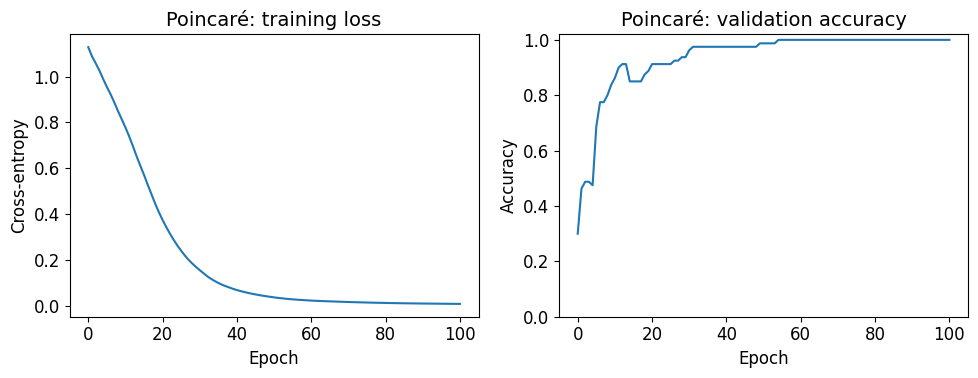

Poincaré train accuracy: 1.000
Poincaré validation accuracy: 1.000


In [16]:
def evaluate_model(
    model,
    x_train,
    y_train,
    x_validation,
    y_validation,
    loss_history,
    validation_accuracy_history,
    model_name,
):
    model.eval()
    with torch.no_grad():
        train_accuracy = (
            model(x_train).argmax(dim=1) == y_train
        ).float().mean().item()
        validation_accuracy = (
            model(x_validation).argmax(dim=1) == y_validation
        ).float().mean().item()

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].plot(loss_history)
    axes[0].set(
        xlabel="Epoch",
        ylabel="Cross-entropy",
        title=f"{model_name}: training loss",
    )
    axes[1].plot(validation_accuracy_history)
    axes[1].set(
        xlabel="Epoch",
        ylabel="Accuracy",
        ylim=(0, 1.02),
        title=f"{model_name}: validation accuracy",
    )
    plt.tight_layout()
    plt.show()

    print(f"{model_name} train accuracy: {train_accuracy:.3f}")
    print(f"{model_name} validation accuracy: {validation_accuracy:.3f}")
    return train_accuracy, validation_accuracy


poincare_train_accuracy, poincare_validation_accuracy = evaluate_model(
    poincare_model,
    x_train,
    y_train,
    x_validation,
    y_validation,
    poincare_loss_history,
    poincare_validation_accuracy_history,
    model_name="Poincaré",
)

### Try the Lorentz model

**Predict:** How will switching from the Poincaré model to the Lorentz model affect the training curve and validation accuracy?

The next cell trains the same architecture with the Lorentz model. Run it and compare the two training curves and validation accuracies.

Epoch   0 | loss 1.1348 | validation accuracy 0.225
Epoch  10 | loss 0.6811 | validation accuracy 1.000
Epoch  20 | loss 0.2509 | validation accuracy 0.988
Epoch  30 | loss 0.0649 | validation accuracy 0.988
Epoch  40 | loss 0.0226 | validation accuracy 0.988
Epoch  50 | loss 0.0120 | validation accuracy 0.988
Epoch  60 | loss 0.0080 | validation accuracy 0.988
Epoch  70 | loss 0.0060 | validation accuracy 0.988
Epoch  80 | loss 0.0049 | validation accuracy 0.988
Epoch  90 | loss 0.0041 | validation accuracy 0.988
Epoch 100 | loss 0.0035 | validation accuracy 0.975


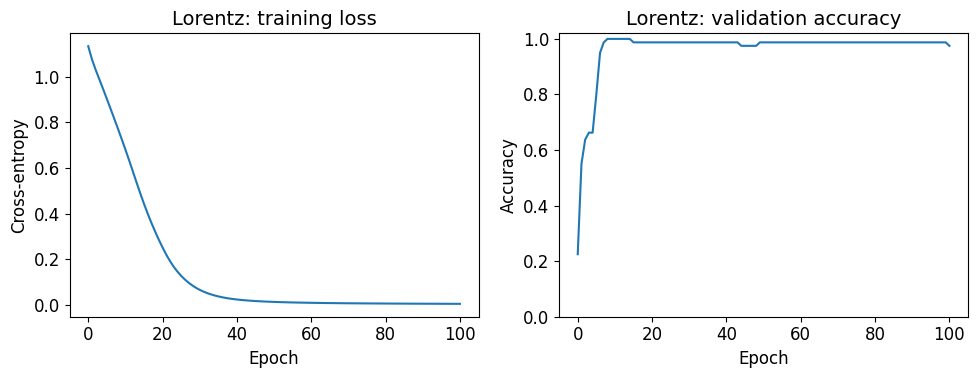

Lorentz train accuracy: 1.000
Lorentz validation accuracy: 0.975


In [17]:
trial_metric = "lorentz"

set_seed(1024)
trial_model = TwoLayerHBNN(metric=trial_metric)
trial_loss_history, trial_validation_accuracy_history = train_model(
    trial_model, x_train, y_train, x_validation, y_validation
)
trial_train_accuracy, trial_validation_accuracy = evaluate_model(
    trial_model,
    x_train,
    y_train,
    x_validation,
    y_validation,
    trial_loss_history,
    trial_validation_accuracy_history,
    model_name=trial_metric.capitalize(),
)

## Takeaways

- The exponential growth of hyperbolic space is well matched to hierarchical structures such as trees.
- Busemann functions generalize Euclidean inner products.
- Horospheres are the hyperbolic counterparts of Euclidean hyperplanes.
- BFC maps hyperbolic features to hyperbolic features.
- BMLR maps hyperbolic features to class logits.
- Both layers can be trained end to end with ordinary PyTorch optimization.
- A unified Busemann framework allows different geometric models to be compared within the same network architecture, without redesigning the network.